## install

In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip install tensorflow

## LIBs

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten ,BatchNormalization, Activation, Input, Dropout
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras import Input, regularizers

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ModuleNotFoundError: No module named 'tensorflow.keras'

## Data Exploration and Visualization

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

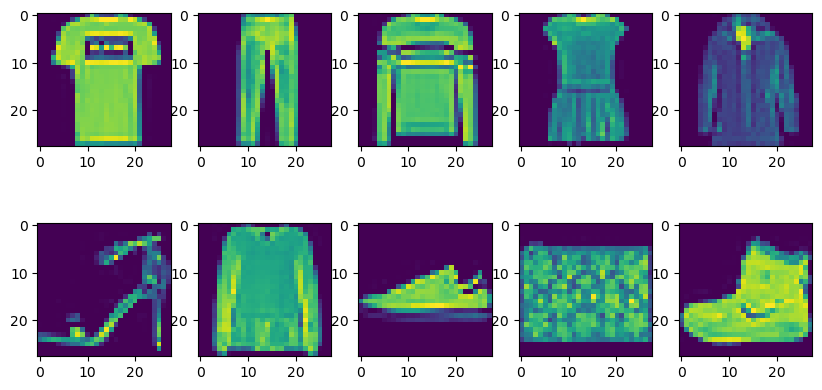

In [ ]:
class_labels = [ "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
plt.figure(figsize=(10,5))
for class_index in range(10):
    index = np.where(y_train == class_index)[0][0]
    img = x_train[index]
    plt.subplot(2,5,class_index + 1)
    plt.imshow(img)
plt.show()

## Feedforward Neural Network Implementation

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

## model build

In [ ]:
def build_and_train_model(hidden_layers=[128, 64], epochs=5, batch_size=32):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_split=0.1,
                        verbose=2)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
    print(f"\n Test Accuracy: {test_acc:.4f}")
    return model, history, test_loss, test_acc

In [ ]:
model, history, test_loss, test_acc = build_train_model(hidden_layers=[128, 64])

Epoch 1/5
1688/1688 - 17s - 10ms/step - accuracy: 0.8208 - loss: 0.5045 - val_accuracy: 0.8520 - val_loss: 0.4199
Epoch 2/5
1688/1688 - 13s - 8ms/step - accuracy: 0.8646 - loss: 0.3731 - val_accuracy: 0.8590 - val_loss: 0.3687
Epoch 3/5
1688/1688 - 14s - 8ms/step - accuracy: 0.8740 - loss: 0.3402 - val_accuracy: 0.8728 - val_loss: 0.3468
Epoch 4/5
1688/1688 - 13s - 8ms/step - accuracy: 0.8847 - loss: 0.3156 - val_accuracy: 0.8762 - val_loss: 0.3333
Epoch 5/5
1688/1688 - 13s - 8ms/step - accuracy: 0.8907 - loss: 0.2963 - val_accuracy: 0.8698 - val_loss: 0.3647
313/313 - 2s - 5ms/step - accuracy: 0.8643 - loss: 0.3836

Test Accuracy: 0.8643


## Backpropagation Algorithm Implementation

In [ ]:
def build_train_model_with_optimizer(hidden_layers=[128, 64], 
                                          optimizer='adam', 
                                          epochs=5, 
                                          batch_size=32):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_split=0.1,
                        verbose=2)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
    print(f"\n Optimizer: {optimizer}, test accuracy: {test_acc:.4f}")

    return model, history, test_loss, test_acc

In [ ]:
build_train_model_with_optimizer(optimizer=SGD())
build_train_model_with_optimizer(optimizer=SGD(momentum=0.9))
build_train_model_with_optimizer(optimizer=SGD(momentum=0.9, nesterov=True))
build_train_model_with_optimizer(optimizer=RMSprop())
build_train_model_with_optimizer(optimizer=Adam())

Epoch 1/5
1688/1688 - 14s - 8ms/step - accuracy: 0.7464 - loss: 0.7649 - val_accuracy: 0.8105 - val_loss: 0.5308
Epoch 2/5
1688/1688 - 11s - 7ms/step - accuracy: 0.8245 - loss: 0.5035 - val_accuracy: 0.8353 - val_loss: 0.4703
Epoch 3/5
1688/1688 - 11s - 7ms/step - accuracy: 0.8405 - loss: 0.4547 - val_accuracy: 0.8395 - val_loss: 0.4549
Epoch 4/5
1688/1688 - 11s - 7ms/step - accuracy: 0.8498 - loss: 0.4274 - val_accuracy: 0.8468 - val_loss: 0.4249
Epoch 5/5
1688/1688 - 11s - 7ms/step - accuracy: 0.8569 - loss: 0.4065 - val_accuracy: 0.8515 - val_loss: 0.4180
313/313 - 2s - 6ms/step - accuracy: 0.8456 - loss: 0.4396

 Optimizer: <keras.src.optimizers.sgd.SGD object at 0x00000232D3D90200>, test accuracy: 0.8456
Epoch 1/5
1688/1688 - 10s - 6ms/step - accuracy: 0.8063 - loss: 0.5389 - val_accuracy: 0.8302 - val_loss: 0.4336
Epoch 2/5
1688/1688 - 8s - 5ms/step - accuracy: 0.8575 - loss: 0.3914 - val_accuracy: 0.8598 - val_loss: 0.3890
Epoch 3/5
1688/1688 - 7s - 4ms/step - accuracy: 0.8703 -

(<Sequential name=sequential_8, built=True>,
 0.3654026985168457,
 0.8727999925613403)

## Hyperparameter Tuning

In [ ]:
def build_and_train_model(hp):
    model = Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hp['num_layers']):
        model.add(Dense(hp['layer_size'], activation=hp['activation'],
                        kernel_regularizer=regularizers.l2(hp['weight_decay'])))
    model.add(Dense(10, activation='softmax'))
    
    opt_type = hp['optimizer'].lower()
    if opt_type == 'sgd':
        optimizer = SGD(learning_rate=hp['lr'])
    elif opt_type == 'momentum':
        optimizer = SGD(learning_rate=hp['lr'], momentum=0.9)
    elif opt_type == 'nesterov':
        optimizer = SGD(learning_rate=hp['lr'], momentum=0.9, nesterov=True)
    elif opt_type == 'rmsprop':
        optimizer = RMSprop(learning_rate=hp['lr'])
    elif opt_type == 'adam':
        optimizer = Adam(learning_rate=hp['lr'])
    else:
        raise ValueError("Unknown optimizer")

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train,
                        epochs=hp['epochs'],
                        batch_size=hp['batch_size'],
                        validation_split=0.1,
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    return test_acc

In [ ]:
grid = [
    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'weight_decay': 0,
     'lr': 1e-3, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu'},
    
    {'epochs': 10, 'num_layers': 4, 'layer_size': 128, 'weight_decay': 0.0005,
     'lr': 1e-3, 'optimizer': 'rmsprop', 'batch_size': 64, 'activation': 'tanh'},

    {'epochs': 5, 'num_layers': 5, 'layer_size': 32, 'weight_decay': 0.5,
     'lr': 1e-4, 'optimizer': 'nesterov', 'batch_size': 16, 'activation': 'sigmoid'},

    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'weight_decay': 0.0005,
     'lr': 1e-3, 'optimizer': 'momentum', 'batch_size': 32, 'activation': 'relu'},

    {'epochs': 10, 'num_layers': 4, 'layer_size': 128, 'weight_decay': 0,
     'lr': 1e-3, 'optimizer': 'sgd', 'batch_size': 64, 'activation': 'relu'}
]

results = []

for i, hp in enumerate(grid):
    acc = build_and_train_model(hp)
    results.append((i+1, acc, hp))
    print(f"Model {i+1}: Accuracy = {acc:.4f} | {hp}")

Model 1: Accuracy = 0.8689 | {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'weight_decay': 0, 'lr': 0.001, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu'}
Model 2: Accuracy = 0.8619 | {'epochs': 10, 'num_layers': 4, 'layer_size': 128, 'weight_decay': 0.0005, 'lr': 0.001, 'optimizer': 'rmsprop', 'batch_size': 64, 'activation': 'tanh'}
Model 3: Accuracy = 0.1000 | {'epochs': 5, 'num_layers': 5, 'layer_size': 32, 'weight_decay': 0.5, 'lr': 0.0001, 'optimizer': 'nesterov', 'batch_size': 16, 'activation': 'sigmoid'}
Model 4: Accuracy = 0.8439 | {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'weight_decay': 0.0005, 'lr': 0.001, 'optimizer': 'momentum', 'batch_size': 32, 'activation': 'relu'}
Model 5: Accuracy = 0.7898 | {'epochs': 10, 'num_layers': 4, 'layer_size': 128, 'weight_decay': 0, 'lr': 0.001, 'optimizer': 'sgd', 'batch_size': 64, 'activation': 'relu'}


## Model Regularization and Optimization

In [ ]:
def build_and_train_model(hp):
    model = Sequential()
    model.add(Input(shape=(784,)))

    reg_type = hp.get('reg_type', None)
    reg_strength = hp.get('reg_strength', 0.0)

    if reg_type == 'l1':
        reg = regularizers.l1(reg_strength)
    elif reg_type == 'l2':
        reg = regularizers.l2(reg_strength)
    elif reg_type == 'l1_l2':
        reg = regularizers.l1_l2(l1=reg_strength, l2=reg_strength)
    else:
        reg = None
        

    for _ in range(hp['num_layers']):
        model.add(Dense(hp['layer_size'], kernel_regularizer=reg))

        if hp.get('batch_norm', False):
            model.add(BatchNormalization())

        model.add(Activation(hp['activation']))

        if 'dropout_rate' in hp and hp['dropout_rate'] is not None:
            model.add(Dropout(hp['dropout_rate']))
            
    model.add(Dense(10, activation='softmax'))
    opt_type = hp['optimizer'].lower()
    if opt_type == 'sgd':
        optimizer = SGD(learning_rate=hp['lr'])
    elif opt_type == 'momentum':
        optimizer = SGD(learning_rate=hp['lr'], momentum=0.9)
    elif opt_type == 'nesterov':
        optimizer = SGD(learning_rate=hp['lr'], momentum=0.9, nesterov=True)
    elif opt_type == 'rmsprop':
        optimizer = RMSprop(learning_rate=hp['lr'])
    elif opt_type == 'adam':
        optimizer = Adam(learning_rate=hp['lr'])
    else:
        raise ValueError("Unsupported optimizer.")

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(x_train, y_train,
                        epochs=hp['epochs'],
                        batch_size=hp['batch_size'],
                        validation_split=0.1,
                        verbose=0)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Test Accuracy: {test_acc:.4f}")
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return model, y_pred, test_acc

In [ ]:
configs = [
    # Baseline (no dropout, no batchnorm, L2 regularization)
    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'reg_type': 'l2', 'reg_strength': 0.0005,
     'lr': 1e-3, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu'},

    # With Dropout (0.2)
    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'reg_type': 'l2', 'reg_strength': 0.0005,
     'lr': 1e-3, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu',
     'dropout_rate': 0.2},

    # With BatchNorm only
    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'reg_type': 'l2', 'reg_strength': 0.0005,
     'lr': 1e-3, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu',
     'batch_norm': True},

    # With Both Dropout + BatchNorm + L1_L2 Regularization
    {'epochs': 5, 'num_layers': 3, 'layer_size': 64, 'reg_type': 'l1_l2', 'reg_strength': 0.001,
     'lr': 1e-3, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'relu',
     'dropout_rate': 0.2, 'batch_norm': True},
]

for i, hp in enumerate(configs):
    acc = build_and_train_model(hp)
    print(f"Model {i+1}: Accuracy = {acc:.4f} | Dropout: {hp.get('dropout_rate')} | BatchNorm: {hp.get('batch_norm')} | Reg: {hp['reg_type']}")


Test Accuracy: 0.8572
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 1: Accuracy = 0.8572 | Dropout: None | BatchNorm: None | Reg: l2
Test Accuracy: 0.8499
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 2: Accuracy = 0.8499 | Dropout: 0.2 | BatchNorm: None | Reg: l2
Test Accuracy: 0.8591
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 3: Accuracy = 0.8591 | Dropout: None | BatchNorm: True | Reg: l2
Test Accuracy: 0.7792
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model 4: Accuracy = 0.7792 | Dropout: 0.2 | BatchNorm: True | Reg: l1_l2


## Model Evaluation

In [ ]:
best_hp = {
    'epochs': 5,
    'num_layers': 3,
    'layer_size': 64,
    'activation': 'relu',
    'optimizer': 'adam',
    'lr': 0.001,
    'batch_size': 32,
    'reg_type': None,
    'reg_strength': 0,
    'dropout_rate': None,
    'batch_norm': False
}

In [ ]:
model, y_pred, test_acc = build_and_train_model(best_hp)

Test Accuracy: 0.8752
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


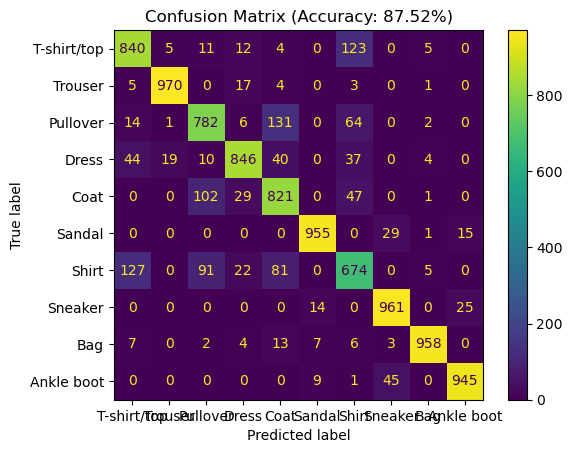

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot()
plt.title(f"Confusion Matrix (Accuracy: {test_acc:.2%})")
plt.show()

## Conclusion